In [1]:
# the libraries
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import pandas as pd
import seaborn as sns
import cartopy.crs as ccrs
from scipy.stats import linregress



from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'


In [2]:

def build_weights(data, datadata, minvalue = -999, latlim = 90.):
    weights = datadata.isel(time = 0) > minvalue
    weights = weights *np.cos( np.deg2rad(data.lat))
    weights = weights*(abs(data.lat)<latlim)
    return weights

def anomaly(glbmean, weights, normalise = False, detrend = False):

    #nanoseconds per century required for fit
    ns_century = 1.e9*3600.*24.*365.*100.                # scaling: nono-seconds to century
    #detrend if desired
    if detrend:
        glbmean = glbmean.groupby('time.month').apply(detrend_monthly)

    
    databymth = glbmean.groupby("time.month")
    mthclim = databymth.mean("time")       # detrended climatological months (seasonal cycle)
    
    dataanom = databymth - mthclim          # detrended interannual annomaly
    if normalise:
        dataanom = dataanom/dataanom.std()
    dataanom = dataanom.rename('anom')   # change variable name
    return dataanom


def detrend_monthly(group):
    ns_century = 1.e9*3600.*24.*365.*100.
    linfit = group.polyfit('time', 1)
    slope = linfit.polyfit_coefficients.isel(degree=0) * ns_century

    trend = xr.polyval(coord=group.time, coeffs=linfit.polyfit_coefficients)
    detrended_group = group - trend.values + group.mean(dim='time')

    return detrended_group


def global_mean(data, datadata, weights):
    datadata_weighted = datadata.weighted(weights)
    weighted_mean = datadata_weighted.mean(('lat', 'lon'))
    return weighted_mean

def lat_bands_gt(data, datadata, minlat,maxlat, detrend = False):
    #select region
    data = data.sel(lat = slice(maxlat,minlat))
    datadata = datadata.sel(lat = slice(maxlat,minlat))
    #calculate anomaly
    data_weights = build_weights(data, datadata)
    data_glbmean = global_mean(data, datadata, data_weights)
    data_glbanom = anomaly(data_glbmean, data_weights, detrend = detrend)
    return data_glbanom


def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds

def encode_time(ds, reference_time = '1958-01-01', period = 'months'):
    ds.time.encoding['calendar'] = '360_day'
    ds.time.encoding['units'] = '{} since {}'.format(period, reference_time)
    return ds







In [3]:
# load nino
fp = '/data/jmex/output/drivers/indices/nino.nc'
nino = decode_time(fp)
ninoOND = nino.where(nino.time.dt.month.isin([10,11,12])).groupby('time.year').mean()
ninoJAS = nino.where(nino.time.dt.month.isin([7,8,9])).groupby('time.year').mean()
ninoJFM = nino.where(nino.time.dt.month.isin([1,2,3])).groupby('time.year').mean()

In [4]:
fp = '/data/jmex/ERA5/monthly/era5_tp.nc'
tp = decode_time(fp)#select rev. time only
#select revtime only
tp = tp.sel(time = slice('1958-01-01', '2023-12-31'))
#select west
tp_west = tp.sel(lat = slice(20,-20), lon = slice(130, 150))

tp_weights = np.cos(np.deg2rad(tp_west.lat))
tp_west_mean = global_mean(tp_west, tp_west.tp, tp_weights).rolling(time = 3, center = True).mean()


#compute the anomaly
tp_west_anom = anomaly(tp_west_mean, tp_weights, detrend = False)

tp_west['box_mean'] = tp_west_mean
tp_west['anom'] = tp_west_anom

In [5]:
fp = '/data/jmex/output/circulation/sst_dashed.nc'
sst = decode_time(fp)

#select western part
sst_west = sst.sel(lat = slice(20,-20), lon = slice(130,150), time = slice('1958-01-01', '2023-12-31') )

#compute weighted average
sst_weights = np.cos(np.deg2rad(sst_west.lat))
sst_west_mean = global_mean(sst_west, sst_west.sst_dashed, sst_weights).rolling(time = 3, center = True, min_periods = 1).mean()

#compute the anomaly
sst_west_anom = anomaly(sst_west_mean, sst_weights, detrend = False)

sst_west['box_mean'] = sst_west_mean
sst_west['anom'] = sst_west_anom

In [6]:
fp = '/data/jmex/output/circulation/W_w500.nc'
W_w500 = xr.open_dataset(fp).sel(time = slice('1958', '2023'))

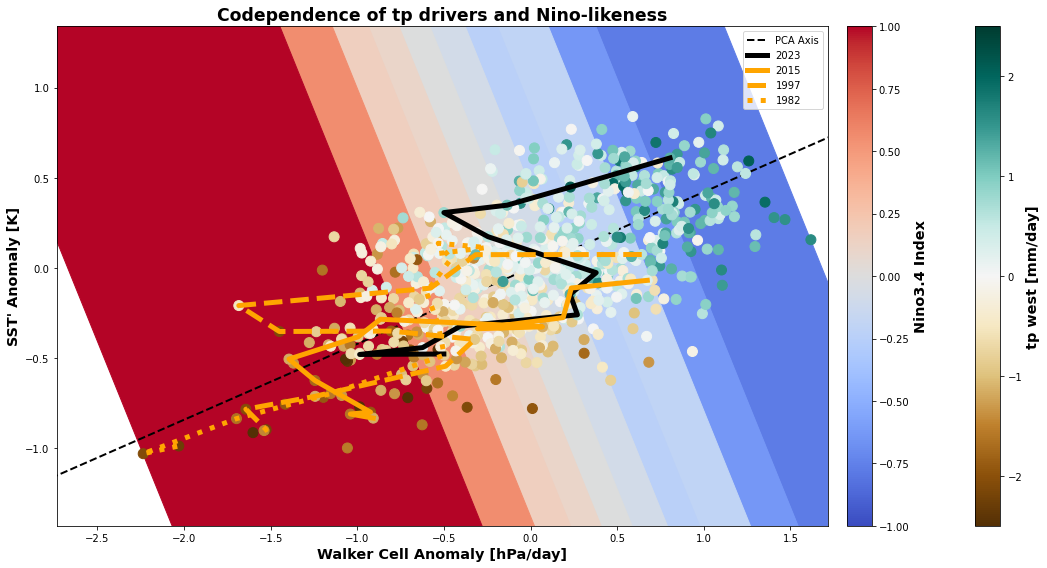

In [7]:

from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

# Step 1: Perform PCA
data = np.vstack([W_w500.w2w, sst_west.anom]).T
pca = PCA(n_components=1)
principal_component = pca.fit_transform(data).flatten()
principal_axis = pca.components_[0]

# Step 2: Divide data into 10 regions
bins = np.percentile(principal_component, np.linspace(0, 100, 11))
region_labels = np.digitize(principal_component, bins) - 1

# Step 3: Compute the mean of the fourth variable for each region
region_means = [nino.nino34[region_labels == i].mean() for i in range(10)]

# Step 4: Create a colormap based on the means of the fourth variable
cmap = plt.get_cmap('coolwarm')
norm = plt.Normalize(-1, 1)
region_colors = cmap(norm(region_means))

# Define function to rotate points by the angle of the principal component
def rotate(points, angle):
    rotation_matrix = np.array([[np.cos(angle), -np.sin(angle)],
                                [np.sin(angle), np.cos(angle)]])
    return points @ rotation_matrix

# Calculate the angle of the principal component
angle = np.arctan2(principal_axis[1], principal_axis[0])

# Plotting the scatter plot
plt.figure(figsize=(16, 8))
sc = plt.scatter(W_w500.w2w, sst_west.anom, c=tp_west.anom, cmap='BrBG', zorder=10, s = 100, vmin = -2.5, vmax = 2.5)

# Plotting the regions
for i in range(10):
    mask = (region_labels == i)
    pc_min = bins[i]
    pc_max = bins[i + 1]
    
    # Define region's boundaries along the principal component
    region_min_proj = pc_min * principal_axis
    region_max_proj = pc_max * principal_axis
    
    # Create corners of the stripes in the principal component space
    stripe_corners = np.array([
        [pc_min, -1000],
        [pc_min,  1000],
        [pc_max,  1000],
        [pc_max, -1000]
    ])
    
    # Rotate corners back to original space
    stripe_corners_rotated = rotate(stripe_corners, -angle)
    
    # Plot the stripe
    plt.fill(stripe_corners_rotated[:, 0], stripe_corners_rotated[:, 1], 
             color=region_colors[i], alpha=1, zorder=1)

# Plot the principal component axis
pc_axis_length = np.abs(principal_component.max() - principal_component.min())
pc_axis_start = principal_component.mean() - pc_axis_length / 2
pc_axis_end = principal_component.mean() + pc_axis_length / 2
plt.plot([-principal_axis[0] * 1000, principal_axis[0] * 1000],  [principal_axis[1] * -1000,principal_axis[1] * 1000], 'k--', lw=2, label='PCA Axis')


"""# Annotate the plot with correlation coefficient
correlation_coef = np.corrcoef(W_w500.w2w, sst_west.anom)[0, 1]
plt.text(0.5, 0.95, f'Correlation Coefficient: {correlation_coef:.2f}', 
         horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
"""
# Add colorbar for the scatter plot
cbar1 = plt.colorbar(sc, label='tp west [mm/day]', pad =-0.01)

# Add colorbar for the regions
cbar2 = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=plt.gca(), orientation='vertical', 
                     label='Nino3.4 Index', pad =0.02)

plt.xlabel('Walker Cell Anomaly [hPa/day]')
plt.ylabel('SST\' Anomaly [K]')
plt.title('Codependence of tp drivers and Nino-likeness')

# Adjust axis limits
plt.xlim(W_w500.w2w.min()-0.5, W_w500.w2w.max()+0.1)
plt.ylim(sst_west.anom.min()-0.4, sst_west.anom.max()+0.5)

w = W_w500.w2w.rolling(time = 1, center = True, min_periods = 1).mean()
s = sst_west.anom.rolling(time = 1, center = True, min_periods = 1).mean()
# Add the line with arrows
plt.plot(w.sel(time='2023'), s.sel(time='2023'), linewidth = 5, c='k', zorder=16, label = '2023')
plt.plot(w.sel(time='2015'), s.sel(time='2015'), linewidth = 5, c='orange', zorder=16, label = '2015')
plt.plot(w.sel(time='1997'), s.sel(time='1997'), linewidth = 5, c='orange', zorder=16, linestyle = '--', label = '1997')
plt.plot(w.sel(time='1982'), s.sel(time='1982'), linewidth = 5, c='orange', zorder=16, linestyle = ':', label = '1982')


plt.legend()





plt.tight_layout()
plt.show()


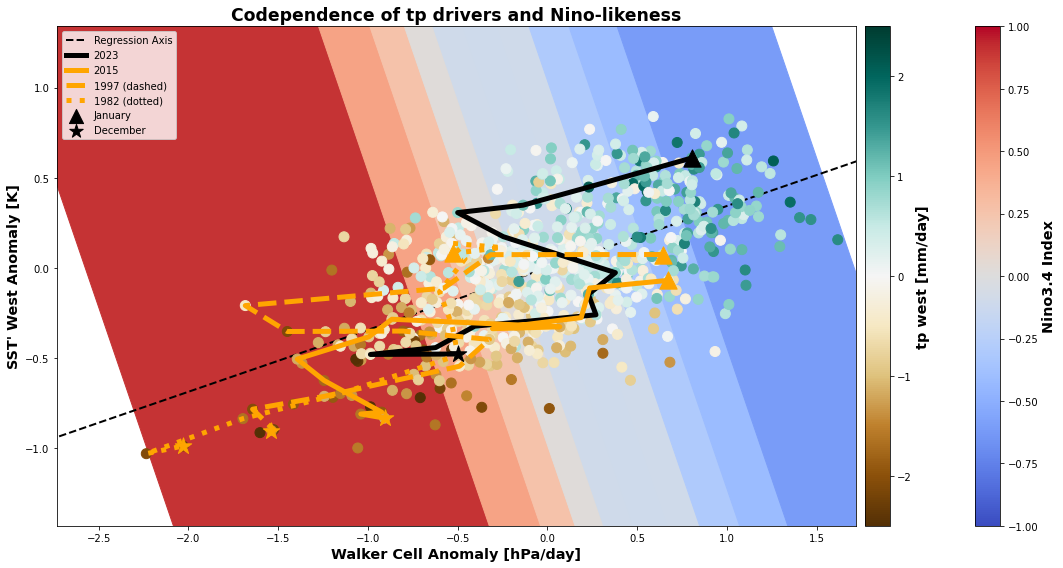

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from matplotlib.colors import ListedColormap

# Assuming W_w500.w2w, sst_west.anom, nino.nino34, and tp_west.anom are available as pandas Series or numpy arrays
data = np.vstack([W_w500.w2w, sst_west.anom]).T

# Step 1: Perform linear regression
X = W_w500.w2w.values.reshape(-1, 1)
y = sst_west.anom.values
reg = LinearRegression()
reg.fit(X, y)

# Get the direction of the principal axis (the regression line)
direction = np.array([1, reg.coef_[0]])
intercept = reg.intercept_

# Project the data onto the regression line
projections = X.flatten() * direction[0] + intercept

# Step 2: Divide data into 10 regions, ensuring all points are included
bins = np.percentile(projections, np.linspace(0, 100, 11))
bins[0] = projections.min() - 2e-1  # Adjust to include all points
bins[-1] = projections.max() + 1e-6

region_labels = np.digitize(projections, bins) - 1

# Step 3: Compute the mean of the fourth variable for each region
region_means = [nino.nino34[region_labels == i].mean() for i in range(10)]

# Step 4: Create a colormap based on the means of the fourth variable
cmap = plt.get_cmap('coolwarm')
norm = plt.Normalize(-1, 1)
region_colors = cmap(norm(region_means))

# Define function to rotate points by the angle of the principal component
def rotate(points, angle):
    rotation_matrix = np.array([[np.cos(angle), -np.sin(angle)],
                                [np.sin(angle), np.cos(angle)]])
    return points @ rotation_matrix

# Calculate the angle of the principal component
angle = np.arctan2(direction[1], direction[0])

# Plotting the scatter plot
plt.figure(figsize=(16, 8))
sc = plt.scatter(W_w500.w2w, sst_west.anom, c=tp_west.anom, cmap='BrBG', zorder=10, s=100, vmin=-2.5, vmax=2.5)

# Plotting the regions
for i in range(10):
    mask = (region_labels == i)
    pc_min = bins[i]
    pc_max = bins[i + 1]
    
    # Define region's boundaries along the principal component
    region_min_proj = pc_min * direction
    region_max_proj = pc_max * direction
    
    # Create corners of the stripes in the principal component space
    stripe_corners = np.array([
        [pc_min, -1000],
        [pc_min,  1000],
        [pc_max,  1000],
        [pc_max, -1000]
    ])
    
    # Rotate corners back to original space
    stripe_corners_rotated = rotate(stripe_corners, -angle)
    
    # Plot the stripe
    plt.fill(stripe_corners_rotated[:, 0], stripe_corners_rotated[:, 1], 
             color=region_colors[i], alpha=1, zorder=1)

# Plot the principal component axis
plt.plot([-direction[0] * 1000, direction[0] * 1000], 
         [-direction[1] * 1000, direction[1] * 1000], 'k--', lw=2, label='Regression Axis')

# Add colorbar for the regions
cbar1 = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=plt.gca(), orientation='vertical', 
                     label='Nino3.4 Index', pad=-0.03)


# Add colorbar for the scatter plot
cbar2 = plt.colorbar(sc, label='tp west [mm/day]', pad=0.01)


plt.xlabel('Walker Cell Anomaly [hPa/day]')
plt.ylabel('SST\' West Anomaly [K]')
plt.title('Codependence of tp drivers and Nino-likeness')

# Adjust axis limits
plt.xlim(W_w500.w2w.min()-0.5, W_w500.w2w.max()+0.1)
plt.ylim(sst_west.anom.min()-0.4, sst_west.anom.max()+0.5)

w = W_w500.w2w.rolling(time=1, center=True, min_periods=1).mean()
s = sst_west.anom.rolling(time=1, center=True, min_periods=1).mean()


# Define the function to plot the line with markers
def plot_line_with_markers(w, s, color, label, linestyle = None):
    plt.plot(w, s, linewidth=5, c=color, zorder=16, label=label, linestyle = linestyle )
    plt.scatter(w.values[0], s.values[0], c=color, marker='^', s=300, zorder=17)  # Triangle at the beginning
    plt.scatter(w.values[-1], s.values[-1], c=color, marker='*', s=300, zorder=17)  # Star at the end

# Add the lines with arrows and markers
plot_line_with_markers(w.sel(time='2023'), s.sel(time='2023'), 'k', '2023')
plot_line_with_markers(w.sel(time='2015'), s.sel(time='2015'), 'orange', '2015')
plot_line_with_markers(w.sel(time='1997'), s.sel(time='1997'), 'orange', '1997 (dashed)', linestyle = '--')
plot_line_with_markers(w.sel(time='1982'), s.sel(time='1982'), 'orange', '1982 (dotted)', linestyle = ':')

# Add legend for markers
plt.scatter([], [], c='k', marker='^', s=200, label='January')
plt.scatter([], [], c='k', marker='*', s=200, label='December')



plt.legend()
plt.tight_layout()
plt.show()
